# Canada Restaurant Analytics
## Exploratory Data Analysis

This notebook explores restaurant data collected from the Google Places API and Yelp Fusion API 
across five Canadian cities, enriched with Statistics Canada 2021 census data. 
The analysis connects restaurant performance metrics to neighbourhood demographics 
and compares data quality and coverage between platforms.

---

## Analytical Questions

1. Do higher income neighbourhoods have higher rated restaurants?
2. Which city has the biggest rating gap between Google and Yelp?
3. Are expensive restaurants actually rated higher than budget ones?
4. Which restaurant categories are most popular in each city?
5. Do restaurants with more reviews tend to have higher or lower ratings?

---


## Setup

In [81]:
import os
import sys
import pandas as pd
from sqlalchemy import create_engine
import urllib.parse
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
sys.path.append(os.path.abspath('../'))

from config.config import CONFIG

db = CONFIG["db"]
params = urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 18 for SQL Server}};"
    f"SERVER=127.0.0.1,1433;"
    f"DATABASE={db['name']};"
    f"UID={db['user']};"
    f"PWD={db['password']};"
    f"TrustServerCertificate=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")


---

## 2.  Google vs Yelp Rating Comparison by City

This analysis compares average restaurant ratings across five Canadian cities between Google and Yelp. Both platforms use a 0-5 star rating scale, allowing for direct comparison of how diners rate restaurants in each city.

In [82]:
query = """
SELECT
    d.city,
    AVG(f.google_rating) AS avg_google_rating,
    AVG(f.yelp_rating) AS avg_yelp_rating
FROM gold.fact_restaurants f
JOIN gold.dim_location d
    ON f.location_key = d.location_key
GROUP BY d.city
ORDER BY avg_google_rating DESC
"""

df = pd.read_sql(query, engine)
df = df.rename(columns={'avg_google_rating': 'Average Google Rating', 'avg_yelp_rating': 'Average Yelp Rating', 'city': 'City'})
display(df.style.hide(axis='index'))


City,Average Google Rating,Average Yelp Rating
Toronto,4.118060,4.210040
Edmonton,4.090816,4.138723
Calgary,4.083892,4.074180
Vancouver,4.044268,4.184140
Montreal,4.030612,4.299078


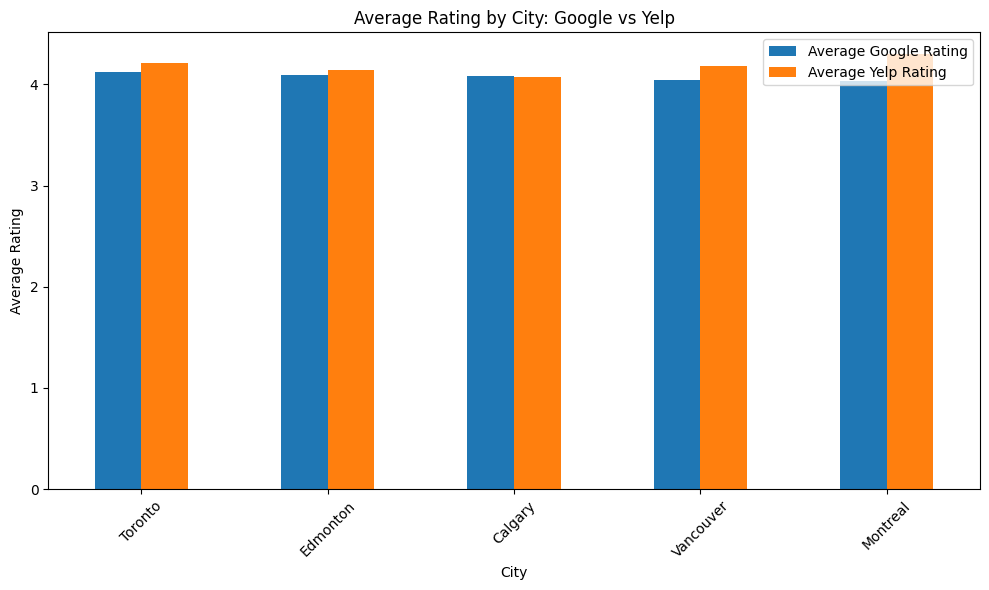

In [83]:
df.plot(
    x='City',
    y=['Average Google Rating', 'Average Yelp Rating'],
    kind='bar',
    figsize=(10, 6),
    title='Average Rating by City: Google vs Yelp',
    ylabel='Average Rating',
    xlabel='City'
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Observations
- Yelp ratings are consistently higher than Google ratings across all cities except Calgary, where Google rates slightly higher (4.08 vs 4.07)
- Montreal shows the largest gap between platforms - Yelp rates restaurants 0.27 stars higher on average
- Vancouver has the lowest Google rating but the second highest Yelp rating, suggesting Yelp users are more generous reviewers in Vancouver
- Toronto has the highest Google rating of all cities
- All cities fall in the 4.0-4.3 range suggesting generally positive dining experiences across Canada

---

## 3. Price Level Analysis

This section examines restaurant pricing across Canadian cities on both Google and Yelp. 
First, we look at how restaurants are distributed across price levels by city and platform. 
Then we explore whether price level has any relationship with restaurant ratings - do more expensive restaurants actually receive better reviews?

In [98]:
query = """
SELECT 
    dl.city,
    f.google_price_level AS price_level,
    'Google' AS source,
    COUNT(*) AS count
FROM gold.fact_restaurants f
JOIN gold.dim_location dl ON f.location_key = dl.location_key
WHERE f.google_price_level IS NOT NULL
GROUP BY dl.city, f.google_price_level

UNION ALL

SELECT
    dl.city,
    f.yelp_price_level AS price_level,
    'Yelp' AS source,
    COUNT(*) AS count
FROM gold.fact_restaurants f
JOIN gold.dim_location dl ON f.location_key = dl.location_key
WHERE f.yelp_price_level IS NOT NULL
GROUP BY dl.city, f.yelp_price_level

ORDER BY city, source, price_level
"""
df = pd.read_sql(query, engine)

price_map = {'$': 'Budget', '$$': 'Moderate', '$$$': 'Pricey', '$$$$': 'Luxury'}
df['price_level'] = df['price_level'].map(price_map)
df_pivot = df.pivot_table(
    index=['city', 'price_level'], 
    columns='source', 
    values='count'
).reset_index()
df_pivot['Google'] = df_pivot['Google'].fillna(0).astype(int)
df_pivot['Yelp'] = df_pivot['Yelp'].fillna(0).astype(int)
df_pivot = df_pivot.rename(columns={'price_level': 'Price Level', 'city': 'City'})

display(df_pivot.style.hide(axis='index'))


City,Price Level,Google,Yelp
Calgary,Budget,116,26
Calgary,Luxury,1,2
Calgary,Moderate,120,133
Calgary,Pricey,19,14
Edmonton,Budget,107,18
Edmonton,Luxury,1,1
Edmonton,Moderate,112,114
Edmonton,Pricey,10,9
Montreal,Budget,69,24
Montreal,Luxury,9,3


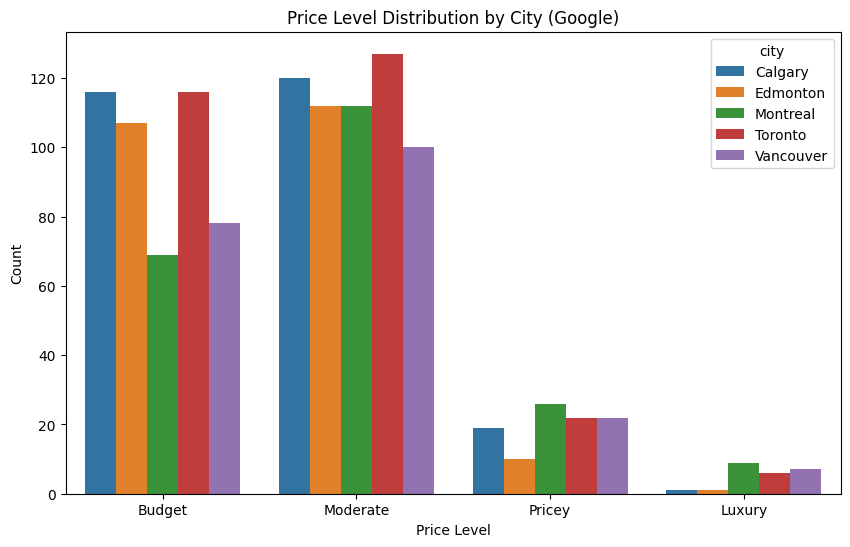

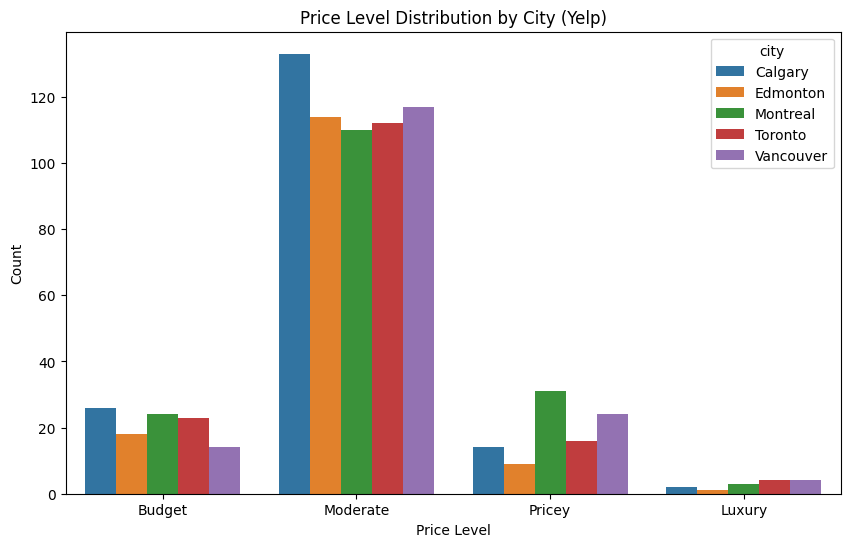

In [99]:
df_chart = df.copy()

order = ['Budget', 'Moderate', 'Pricey', 'Luxury']

df_google = df_chart[df_chart['source'] == 'Google']
df_yelp = df_chart[df_chart['source'] == 'Yelp']

# Google chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df_google, x='price_level', y='count', hue='city', order=order)
plt.title('Price Level Distribution by City (Google)')
plt.xlabel('Price Level')
plt.ylabel('Count')
plt.show()

# Yelp chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df_yelp, x='price_level', y='count', hue='city', order=order)
plt.title('Price Level Distribution by City (Yelp)')
plt.xlabel('Price Level')
plt.ylabel('Count')
plt.show()

### Key Observations
- `$$` (Moderate) is the dominant price level across all cities on both platforms
- Google captures significantly more budget (`$`) restaurants than Yelp in every city
- Yelp skews toward moderate pricing — likely reflecting platform bias in which restaurants choose to list
- Calgary has the highest concentration of moderate-priced restaurants on Yelp (133)
- Montreal has the most pricey (`$$$`) restaurants relative to its size on both platforms
- Luxury (`$$$$`) restaurants are rare across all cities and both platforms

---

## 4. 